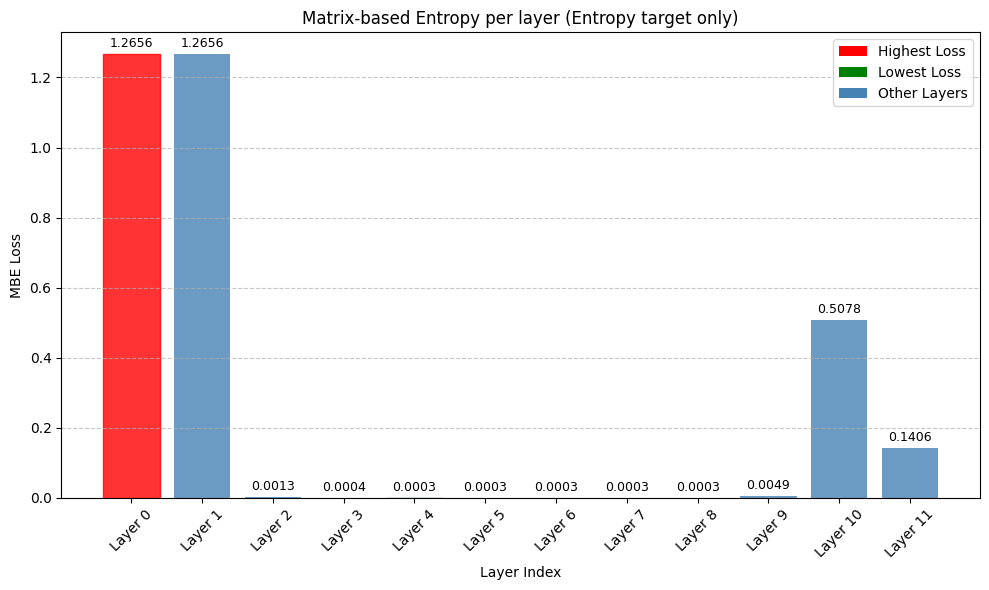

In [51]:
# mbe_0 loss: 1.2656 mbe_1 loss: 1.2656 mbe_2 loss: 0.0013 mbe_3 loss: 0.0004 mbe_4 loss: 0.0003 mbe_5 loss: 0.0003 mbe_6 loss: 0.0003 mbe_7 loss: 0.0003 mbe_8 loss: 0.0003 mbe_9 loss: 0.0049 mbe_10 loss: 0.5078 mbe_11 loss: 0.1406

mbe_loss = [1.2656, 1.2656, 0.0013, 0.0004, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0049, 0.5078, 0.1406]
from src.utils import plot_mbe 
plot_mbe(mbe_loss)

#### Algorithm (a). Enhanced Oscillation

In [1]:
# Algorithm 1. Enhancing Oscillation
# Algorithm 2. Gated Regularization 
# - Metric: Just don't collapse the MBE loss. 


# Test with (1). 
# Again we'd need a toy module for testing purpose ... 

from torch import nn 
from src.model import * 
from src.rank_regularizer import patch_mbe2, patch_mbe2_diff
from src.rank_regularizer import mbe_alpha2_exact

def patch_mbe2(x, patch_size=8): 
    B, S, D = x.shape 
    assert S % patch_size == 0, "Sequence length must be divisible by patch size"
    num_patches = S // patch_size
    x_reshaped = x.reshape(B, num_patches, patch_size, D).reshape(-1, patch_size, D)    
    mbe_values = mbe_alpha2_exact(x_reshaped)
    return mbe_values.mean() 


class Toy(nn.Module): 

    def __init__(self, config): 
        super().__init__() 
        self.num_layers = config.n_layer 
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ))
        self.lm_head = CastedLinear(config.n_embd, config.vocab_size)
        self.lm_head.weight.data.zero_() # @Grad62304977

    def forward(self, idx, target): 
        S = idx.shape[1]
        def causal_mask(b, h, q_idx, kv_idx): 
            return q_idx >= kv_idx 
        block_mask = create_block_mask(causal_mask, None, None, S, S, device="cpu", _compile=True)
        
        x = self.transformer.wte(idx)
        x = norm(x) 
        x0 = x 
        v1 = None 
        loss_dict = {}
        
        for i in range(self.num_layers): 
            x, v1 = self.transformer.h[i](x, v1, x0, block_mask)
            # loss_dict[f"mbe_{i}"] = patch_mbe2(x)
            loss_dict[f"diff_mbe_{i}"] = patch_mbe2_diff(x)
        
        x = norm(x)
        logits = self.lm_head(x)
        logits = 30 * torch.tanh(logits / 30)
        logits = logits.float() 
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), target.view(-1))
        loss_dict["entropy"] = loss 
        return loss_dict 


def get_batch(B=4, S=8): 
    input = torch.randint(0, 64, (B, S), dtype=torch.int32)
    target = torch.randint(0, 64, (B, S), dtype=torch.int64)
    return input, target 

from src.pcgrad import YetAnotherMixer2

cfg = GPTConfig(n_layer=4, n_head=2, n_embd=16, vocab_size=64)
model = Toy(cfg)     
mixer = YetAnotherMixer2(model, "entropy", scale_factor=1.2)
   

In [9]:
for p in model.parameters(): 
    if p.requires_grad: 
        p.grad = torch.zeros_like(p)
        
# loss computation 
train_accumulation_steps = 8
for i in range(train_accumulation_steps):
    input, target = get_batch()
    loss_dict = model(input, target)
    if i % 2 == 0: 
        loss_dict = {"entropy": loss_dict['entropy']}
    else: 
        loss_dict = {"diff_mbe_2": loss_dict['diff_mbe_2']} 

    mixer.backward_info(loss_dict)
    # mixer.naive_backward_info(loss_dict)
    # mixer.backward(loss_dict)
    # mixer.naive_backward(loss_dict)

#### Algorithm (c). Potential Based Reward Shaping

In [ ]:
import torch 
from src.rank_regularizer import mbe_alpha2_exact
# give me an example to work with


def mbe_alpha2_exact2(Z, detach=False, epsilon=1e-7):
    gram = torch.einsum("bpid,bpjd->bpij", Z, Z)
    if detach: 
        gram_trace = torch.diagonal(gram.detach(), dim1=2, dim2=3).sum(dim=2)
    else:
        gram_trace = torch.diagonal(gram, dim1=2, dim2=3).sum(dim=2)
    gram_sq = gram.pow(2).sum(dim=(2,3))
    return -torch.log((gram_sq + epsilon) / (gram_trace.pow(2) + epsilon))

def patch_mbe2_diff(x, patch_size=8, shift=1): 
    x_patches = x.unfold(dimension=1, size=patch_size, step=shift)
    mbe_values = mbe_alpha2_exact2(x_patches)
    mbe_diff = torch.diff(mbe_values, dim=1).mean()
    return mbe_diff

#### Algorithm (b). Gated Regularization

In [3]:
# Working on scheduler object which decides when we don't regularize -- we don't need to adjust weightage at all here. 
# - Scheduler decides whether to 'shut down' regularization | - composer decides how to compose gradients (weightage is included)
# - need to record historical lowest entropy loss 

from src.utils import RRScheduler

scheduler = RRScheduler(num_accumulation_steps=1, total_iterations=1, start_layer=0, end_layer=1, main_loss_name="entropy", 
                        full_mbe=False, switch_phase=True, 
                        entropy_patience=4, entropy_min_delta=0.001, 
                        mbe_patience=4, mbe_min_delta=0.001)

# randomize a loss value as torch.tensor
import torch 

loss_record = []
for step in range(10): 
    print("step", step)
    loss_dict = {"entropy": torch.randn(1), "mbe_0": torch.randn(1), "mbe_1": torch.randn(1)}
    scheduler.step(loss_dict)
    loss_record.append(loss_dict)
    
    
# Observation: 
# 1. Better compression should not drag you out of memorization phase. 
# 2. Better memorization should not drag you into compression phase. 
# 3. However, horrible memorization should drag you out of compression phase and back into memorization phase. 


step 0
Conditions:
 better_memorization: False
 better_compression: False
 no_patience_for_memorization: False
 no_patience_for_compression: False
 worse_memorization: False
 current phase: Memorization

step 1
Conditions:
 better_memorization: False
 better_compression: False
 no_patience_for_memorization: False
 no_patience_for_compression: False
 worse_memorization: True
 current phase: Memorization

step 2
Conditions:
 better_memorization: False
 better_compression: False
 no_patience_for_memorization: False
 no_patience_for_compression: False
 worse_memorization: True
 current phase: Memorization

step 3
Conditions:
 better_memorization: False
 better_compression: True
 no_patience_for_memorization: True
 no_patience_for_compression: False
 worse_memorization: True
 current phase: Memorization

--> Switch to Compression Phase
step 4
Conditions:
 better_memorization: False
 better_compression: True
 no_patience_for_memorization: True
 no_patience_for_compression: False
 worse_memor

In [4]:
scheduler.phase

1

In [5]:
scheduler.rr_layer_index

[]

In [13]:
# scheduler.phase
import numpy as np 
# boolen showing below is not a real number (np.inf)
np.inf - 3. == np.inf

True

#### Animation on MBE evolution

In [1]:
from src.utils import extract_mbe_values, create_mbe_animation

from info import exp_3a1, exp_baseline, exp_3a2
from info import exp_3b1, exp_3b2, exp_3b3, exp_3b4, exp_3c1, exp_3c2, exp_3c3, exp_3a4

# animation on mbe for all layers across iterations, for both exp

baseline_mbe, baseline_label = extract_mbe_values(exp_baseline)
exp_3a1_mbe, exp_3a1_label = extract_mbe_values(exp_3a1)
exp_3a2_mbe, exp_3a2_label = extract_mbe_values(exp_3a2)
exp_3a4_mbe, exp_3a4_label = extract_mbe_values(exp_3a4)
exp_3b1_mbe, exp_3b1_label = extract_mbe_values(exp_3b1)
exp_3b2_mbe, exp_3b2_label = extract_mbe_values(exp_3b2)
exp_3b3_mbe, exp_3b3_label = extract_mbe_values(exp_3b3)
exp_3b4_mbe, exp_3b4_label = extract_mbe_values(exp_3b4)
exp_3c1_mbe, exp_3c1_label = extract_mbe_values(exp_3c1)
exp_3c2_mbe, exp_3c2_label = extract_mbe_values(exp_3c2)
exp_3c3_mbe, exp_3c3_label = extract_mbe_values(exp_3c3)

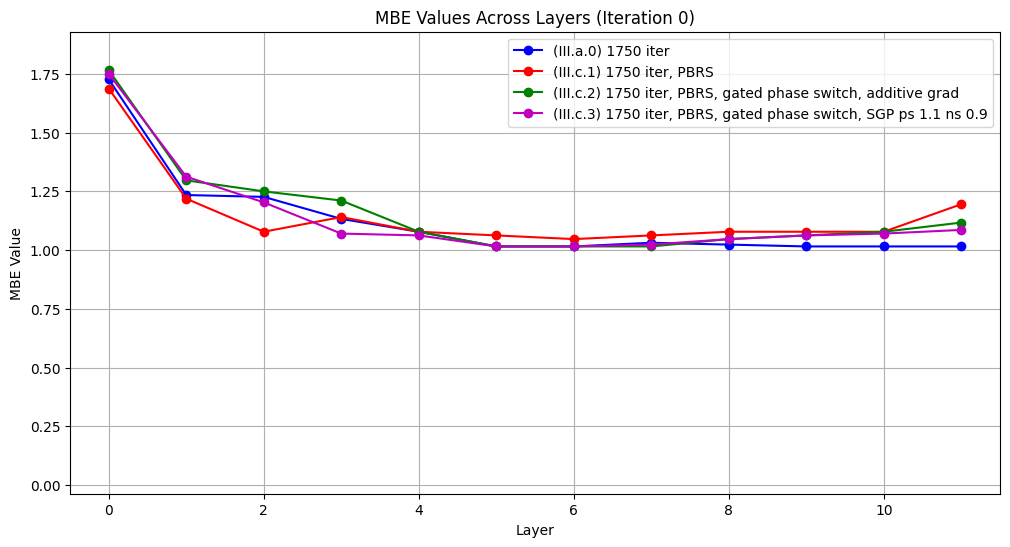

In [3]:

# Example usage with the existing data:
data_list = [baseline_mbe, exp_3c1_mbe, exp_3c2_mbe, exp_3c3_mbe]
label_list = [baseline_label, exp_3c1_label, exp_3c2_label, exp_3c3_label]

ani = create_mbe_animation(data_list, label_list)

In [5]:
0.33 / 3.30

0.1

In [1]:
def parse_record(txt_file):
    with open(txt_file, 'r') as f:
        record = f.read()
        
    results = {}
    for line in record.split('\n'):
        if "mbe_0" not in line:
            continue
            
        # Extract step number
        step_part = line.split(' ')[0]
        step = int(step_part.split(':')[1].split('/')[0])
        
        # Extract all MBE values and entropy
        mbe_values = {}
        parts = line.split(' ')
        for i in range(len(parts)):
            if "mbe_" in parts[i] and "loss:" in parts[i+1]:
                mbe_key = parts[i]
                mbe_value = float(parts[i+2])
                mbe_values[mbe_key] = mbe_value
            elif "entropy" in parts[i] and "loss:" in parts[i+1]:
                mbe_values["entropy"] = float(parts[i+2])
                
        results[step] = mbe_values
    
    return results

# Parse the record
parsed_data = parse_record("record.txt")
print(f"Parsed {len(parsed_data)} steps of data")

Parsed 15 steps of data


In [2]:
parsed_data

{0: {'mbe_0': 2.0156,
  'mbe_1': 2.0156,
  'mbe_2': 2.0156,
  'mbe_3': 2.0156,
  'mbe_4': 2.0156,
  'mbe_5': 2.0156,
  'mbe_6': 2.0156,
  'mbe_7': 2.0156,
  'mbe_8': 2.0156,
  'mbe_9': 2.0156,
  'mbe_10': 2.0156,
  'mbe_11': 2.0156,
  'entropy': 10.8258},
 125: {'mbe_0': 1.7266,
  'mbe_1': 1.2578,
  'mbe_2': 1.25,
  'mbe_3': 1.2188,
  'mbe_4': 1.0703,
  'mbe_5': 1.0156,
  'mbe_6': 1.0156,
  'mbe_7': 1.0156,
  'mbe_8': 1.0234,
  'mbe_9': 1.0625,
  'mbe_10': 1.0625,
  'mbe_11': 1.0625,
  'entropy': 4.4609},
 250: {'mbe_0': 1.2109,
  'mbe_1': 1.0938,
  'mbe_2': 1.2188,
  'mbe_3': 1.2109,
  'mbe_4': 1.0312,
  'mbe_5': 0.8125,
  'mbe_6': 0.8594,
  'mbe_7': 0.7891,
  'mbe_8': 0.8672,
  'mbe_9': 0.8828,
  'mbe_10': 0.8125,
  'mbe_11': 0.6836,
  'entropy': 4.0386},
 375: {'mbe_0': 0.9922,
  'mbe_1': 0.9922,
  'mbe_2': 1.0781,
  'mbe_3': 1.0781,
  'mbe_4': 1.0,
  'mbe_5': 0.5391,
  'mbe_6': 0.6172,
  'mbe_7': 0.5234,
  'mbe_8': 0.5352,
  'mbe_9': 0.5156,
  'mbe_10': 0.5039,
  'mbe_11': 0.5156,
